Κατέβασμα Απαραίτητων Βιβλιοθηκών

In [ ]:
!pip install pandas requests beautifulsoup4 lxml openpyxl xlrd

import os
import re
from io import BytesIO
from urllib.parse import urljoin

import requests
import pandas as pd
from bs4 import BeautifulSoup

In [ ]:
BASE = "https://parismou.org"
# Έτη από 2014 έως και 2020
YEARS = range(2014, 2021)

# URL της σελίδας κάθε έτους με τις λίστες κρατήσεων
YEAR_PAGE = BASE + "/Statistics%26Current-Lists/monthly-detentions/detentionlists-{year}"

# Φάκελοι και αρχεία εξόδου
OUT_DIR = "parismou_detentionlists_2014_2020"
DOWNLOAD_DIR = os.path.join(OUT_DIR, "downloads")
OUT_CSV = os.path.join(OUT_DIR, "detentionlists_2014_2020_merged.csv")

# Δημιουργία φακέλου λήψεων αν δεν υπάρχει
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# Δημιουργία session για τα requests με custom User-Agent
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0 (compatible; DataDownloadScript/1.0)"})

def get_excel_links(year: int):
    """
    Παίρνει όλα τα links προς αρχεία Excel (.xls, .xlsx)
    από τη σελίδα του συγκεκριμένου έτους.
    """
    url = YEAR_PAGE.format(year=year)
    r = session.get(url, timeout=60)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "lxml")
    links = []
    for a in soup.select("a[href]"):
        href = (a.get("href") or "").strip()
        # Κρατάμε μόνο συνδέσμους προς Excel
        if re.search(r"\.(xls|xlsx)$", href, re.IGNORECASE):
            links.append(urljoin(BASE, href))

    # Αφαίρεση διπλότυπων links διατηρώντας τη σειρά
    seen = set()
    unique = []
    for u in links:
        if u not in seen:
            unique.append(u)
            seen.add(u)

    return unique

def safe_filename(url: str):
    """
    Δημιουργεί ασφαλές όνομα αρχείου από το URL
    (χωρίς περίεργους χαρακτήρες).
    """
    name = os.path.basename(url.split("?")[0])
    name = re.sub(r"[^A-Za-z0-9._-]+", "_", name)
    return name

def read_excel_from_url(url: str) -> pd.DataFrame:
    """
    Κατεβάζει αρχείο Excel από URL και το διαβάζει σε pandas DataFrame.
    Προσπαθεί αυτόματα engine, και αν αποτύχει δοκιμάζει xlrd ή openpyxl.
    """
    r = session.get(url, timeout=120)
    r.raise_for_status()
    data = BytesIO(r.content)


    try:
        return pd.read_excel(data, dtype=str)
    except Exception:
        data.seek(0)
        try:
            # Για παλιά .xls
            return pd.read_excel(data, engine="xlrd", dtype=str)
        except Exception:
            data.seek(0)
            # Για .xlsx
            return pd.read_excel(data, engine="openpyxl", dtype=str)

def extract_year_month(url_or_name: str):
    """
    Εξάγει year-month από το όνομα αρχείου ή URL,
    π.χ. 2014-01, 2020-12 κτλ.
    """
    m = re.search(r"(20\d{2})[-_ ](0[1-9]|1[0-2])", url_or_name)
    if m:
        return f"{m.group(1)}-{m.group(2)}"
    return ""

all_frames = []

# Βρόχος για κάθε έτος
for year in YEARS:
    excel_links = get_excel_links(year)
    print(f"{year}: found {len(excel_links)} excel files")

    # Βρόχος για κάθε αρχείο Excel του έτους
    for i, link in enumerate(excel_links, 1):
        fname = safe_filename(link)
        fpath = os.path.join(DOWNLOAD_DIR, fname)

        print(f"  ({i}/{len(excel_links)}) downloading+reading: {fname}")

        # Κατέβασμα και αποθήκευση τοπικού αντιγράφου
        resp = session.get(link, timeout=120)
        resp.raise_for_status()
        with open(fpath, "wb") as f:
            f.write(resp.content)

        # Ανάγνωση αρχείου σε dataframe
        df = read_excel_from_url(link)

        # Προσθήκη στηλών προέλευσης
        df["source_url"] = link
        df["source_file"] = fname
        df["year_month"] = (
            extract_year_month(fname)
            or extract_year_month(link)
            or ""
        )

        all_frames.append(df)

# Συνένωση όλων των dataframes σε ένα
merged = pd.concat(all_frames, ignore_index=True)

# Καθαρισμός ονομάτων στηλών
merged.columns = [str(c).strip() for c in merged.columns]

# Δημιουργία φακέλου εξόδου αν δεν υπάρχει
os.makedirs(OUT_DIR, exist_ok=True)

# Αποθήκευση σε CSV
merged.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print("\nDONE ")
print("Merged rows:", len(merged))
print("Merged columns:", len(merged.columns))
print("Saved:", OUT_CSV)


2014: found 12 excel files
  (1/12) downloading+reading: 2014-01_20DetentionListinExcel.xls
  (2/12) downloading+reading: 2014-02_20DetentionListinExcel.xls
  (3/12) downloading+reading: 2014-03_20DetentionListinExcel.xls
  (4/12) downloading+reading: 2014-04_20DetentionListinExcel.xls
  (5/12) downloading+reading: 2014-05_20DetentionListinExcel.xls
  (6/12) downloading+reading: 2014-06_20DetentionListinExcel.xls
  (7/12) downloading+reading: 2014-07_20DetentionListinExcel.xls
  (8/12) downloading+reading: 2014-08_20DetentionListinExcel.xls
  (9/12) downloading+reading: 2014-09_20DetentionListinExcel.xls
  (10/12) downloading+reading: 2014-10_20DetentionListinExcel.xls
  (11/12) downloading+reading: 2014-11_20DetentionListinExcel.xls
  (12/12) downloading+reading: 2014-12_20DetentionListinExcel.xls
2015: found 12 excel files
  (1/12) downloading+reading: 2015-01_20DetentionListinExcel_0.xls
  (2/12) downloading+reading: 2015-02_20DetentionListinExcel_0.xls
  (3/12) downloading+reading:

In [ ]:
INPUT_CSV = "parismou_detentionlists_2014_2020/detentionlists_2014_2020_merged.csv"
OUTPUT_CSV = "final_defects_with_context_2014_2020.csv"

CERT_MARKER = "Certifier.Description"
DEF_MARKER  = "DEF_DefectiveItemDescr"


TEXT_COL = None

#Φόρτωση Δεδομένων
df = pd.read_csv(INPUT_CSV, dtype="string", low_memory=False)

# Αυτόματος εντοπισμός στήλης κειμένου
def detect_text_col(df: pd.DataFrame) -> str:
    candidates = []
    for c in df.columns:
        s = df[c].astype("string")
        if s.eq(CERT_MARKER).any() or s.eq(DEF_MARKER).any():
            candidates.append(c)

    if candidates:
        return candidates[0]

    # Εναλλακτικά: αναζήτηση ως υποσυμβολοσειρά
    for c in df.columns:
        s = df[c].astype("string")
        if s.str.contains(CERT_MARKER, na=False).any() or s.str.contains(DEF_MARKER, na=False).any():
            return c

    raise ValueError(
        f"Δεν βρέθηκε στήλη που να περιέχει '{CERT_MARKER}' ή '{DEF_MARKER}'. "
        "Δώσε χειροκίνητα το TEXT_COL."
    )

if TEXT_COL is None:
    TEXT_COL = detect_text_col(df)

print(f"Using TEXT_COL = {TEXT_COL}")

#Κρατάμε τις στήλες μέχρι την στήλη κειμένου
cut_idx = df.columns.get_loc(TEXT_COL)
df = df.iloc[:, :cut_idx + 1].copy()

cols_before = list(df.columns[:cut_idx])

df[TEXT_COL] = df[TEXT_COL].astype("string").str.strip()
text_is_blank = df[TEXT_COL].isna() | (df[TEXT_COL] == "")

#Εντοπισμός εγγραφών και αυτόματη συμπλήρωση κειμένου
has_left_data = df[cols_before].notna().any(axis=1)
entry_start_mask = has_left_data & text_is_blank

df["_entry_id"] = entry_start_mask.cumsum()

# Αφαίρεση γραμμών πριν την πρώτη εγγραφή
df = df[df["_entry_id"] > 0].copy()

# Συμπλήρωση στοιχείων εγγραφής προς τα κάτω
df[cols_before] = df.groupby("_entry_id")[cols_before].ffill()

#Κρατάμε τα defects
col = df[TEXT_COL]

cert_mask = col.eq(CERT_MARKER)
def_mask  = col.eq(DEF_MARKER)

# Δημιουργία block για κάθε cert μέσα στην εγγραφή
df["_block_id"] = cert_mask.groupby(df["_entry_id"]).cumsum()

# Μετρητής γραμμών μετά το def
df["_after_def"] = def_mask.groupby([df["_entry_id"], df["_block_id"]]).cumsum()

# Κράταme μόνο τις γραμμές που είναι πραγματικά defects
df_final = df[
    (df["_block_id"] > 0) &
    (df["_after_def"] >= 1) &
    (~cert_mask) &
    (~def_mask)
].copy()

# Αφαίρεση άδειων γραμμών defect
df_final = df_final[df_final[TEXT_COL].str.strip().ne("")]

# Καθαρισμός βοηθητικών στηλών
df_final = df_final.drop(columns=["_entry_id", "_block_id", "_after_def"], errors="ignore")

#Δημιουργία csv
df_final.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(" DONE")
print(f"Saved as : {OUTPUT_CSV}")
print(f"Rows out : {len(df_final)}")
print(f"Cols out : {df_final.shape[1]}")


Using TEXT_COL = Unnamed: 16
 DONE
Saved as : final_defects_with_context_2014_2020.csv
Rows out : 20826
Cols out : 17


In [ ]:
def norm(x) -> str:
    if pd.isna(x):
        return ""
    s = str(x).replace("&amp;", "&")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def compiled(patterns):
    return [re.compile(p, flags=re.IGNORECASE) for p in patterns]

#Κανόνες κατηγοριοποίησης
RULES = [


    # ISM

    ("ISM (International Safety Management)", compiled([
        r"\bism\b",
        r"\bsms\b|safety management system",
        r"safety management certificate|\bsmc\b",
        r"document of compliance\s*\(doc/?\s*ism\)|document of compliance\s*\(doc/ism\)",
        r"\bdoc\b(?![a-z])",


        r"maintenance and inspections",
        r"maintenance/duplication of equipment",
        r"on board training and instructions",
        r"crew training and familiarization",
        r"crew familiarization with emergency systems",
        r"evaluation of crew performance",
        r"evaluation of crew performance\s*\(fire drills\)",
        r"record of drills and steering gear tests",
        r"operational procedures",
        r"operational procedures for engines or equipment",
        r"shipboard working arrangements",
        r"functional requirements",
        r"manning specified by the minimum safe manning doc",


        r"entry dangerous spaces",
        r"enclosed space entry and rescue drills",
    ])),


    # MLC 2006

    ("MLC, 2006 (Maritime Labour Convention)", compiled([
        r"\bmlc\b|maritime labour",
        r"maritime labour certificate",
        r"declaration of maritime labour compliance",
        r"report of inspection on mlc,?2006",
        r"\bwages?\b|non-payment of wages|calculation and payment of wages",
        r"collective bargaining agreement",
        r"record of employment",
        r"seafarers'? employment agreement|\bsea\b",
        r"procedure for complaint",
        r"maximum hours of work|min(imum)? hours of rest",
        r"records of seafarers'? daily hours of work or rest",
        r"fitness for duty\b|fitness for duty - intoxication|fitness for duty - work and rest hours",
        r"minimum age|night working",
        r"medical certificate|certificate for medical care|medical fitness|medical care onboard|medical care onboard or ashore",
        r"medical equipment|medical chest|medical guide",
        r"training and qualification of ship's cook|ship's cook",
        r"sleeping room|messroom|recreational facilities|hospital accomodation|sickbay|sanitary facilities|laundry|adequate locker",
        r"heating|air conditioning|ventilation \(accommodation\)|ventilation \(working spaces\)",
        r"provisions|food personal hygiene|food temperature|nutritional value|cold room|cold room temperature|temperature control|provisions quality|provisions quantity",
        r"on board programme for the prevention of occupational injuries|occupational injuries and deaseases|occupational injuries and diseases",
        r"exposure to harmful levels|noise|vibration|ambient factors",
        r"training and qualification.*mlc|personnal safety training|evidence of basic training",
        r"minimum safe manning document",
        r"estabilishment of working language onboard|working language onboard",
        r"doc\. evidence for personnel on passenger ships",
        r"direct openings into sleeping rooms cargo/mach\.",
    ])),


    # Pollution Prevention

    ("Pollution Prevention", compiled([
        r"\bmarpol\b|pollution report",
        r"international oil pollution prevention|\biopp\b",
        r"international air pollution cert\.?|international air pollution certificate|engine international air pollution prev\. cert\.?|diesel engine relating to air pollution control",
        r"sulphur oxides|sulphur content of fuel used",
        r"bunker delivery notes|fuel change-over procedure|quality of fuel oil",
        r"international sewage pollution prevention cert\.?|sewage treatment plant|sewage comminuting|sewage discharge connection",
        r"garbage management plan|garbage record book|garbage shipboard handling|other marpol\s*annex\s*v|other marpol\s*annex v|annex v",
        r"\b15\s*ppm\b|oil/water interface detector",
        r"oil disch\.* monitoring and control system|oil discharge monitoring",
        r"retention of oil on board|oil and oily mixtures from machinery spaces",
        r"control of discharge|pumping, piping and discharge arrangements|standard disch\. conn\.",
        r"suspected of discharge violation|ballast water discharge violation",
        r"sopep|shipboard marine pollution emergency|shipboard marine pollution emergency operations|shipboard mar\.poll\.emergency plan|shipboard mar\.poll\.emergency plan for nls",
        r"ballast water management certificate|ballast water management plan|ballast water record book|ballast water management system|other bwm",
        r"segregation of oil and water ballast",
        r"residue disch\.systems|residue disch\. systems",
        r"incinerator incl\.?operations|incinerator",
        r"emergency cleaning devices",
        r"declaration of afs compliance|afs supporting documentation",
        r"ozone-depleting substances|asbestos containing materials",
        r"international energy efficiency certificate|ship energy efficiency management plan",
        r"other marpol annex ii|other marpol annex iv|other marpol annex i|other \(marpol annex i\)|other \(marpol annex iv\)",
    ])),


    # Certificates & Documentation

    ("Certificates & Documentation", compiled([
        r"certificate|cert\.",
        r"certificate for rating for watchkeeping",
        r"cert for personnel on survival craft\s*&\s*rescue boat",
        r"endorsement by flagstate|endorsement",
        r"continuous synopsis record|\bcsr\b",
        r"tonnage certificate",
        r"conformance test report",
        r"survey report file|thickness measurement report|statement of compliance|report of inspection",
        r"technical files|monitoring manual|type approval equipment|evaluation, testing and approval",
        r"civil liability for bunker oil pollution damage cert",
        r"civil liability for oil pollution damage cert",
        r"certificate.*financial security|financial security",
        r"international ship security certificate|issc",
        r"ship security officer certificate|security awareness training",
        r"cargo ship safety (equipment|construction|radio)|cargo ship safety\b|passenger ship safety",
        r"operational limitations for passenger ships",
        r"load lines|freeboard marks",
        r"document of compliance dangerous goods|dangerous goods code",
        r"oil record book|radio log|compass correction log|log-books?/compulsory entries|navigation records",
        r"marking of imo number",
        r"p&a manual",
        r"stability information booklet",
        r"cargo securing manual",
        r"booklet for bulk cargo loading",
        r"sts operation plan|records of sts operations",
        r"authorization for grain carriage|grain",
        r"cargo density declaration",
        r"performance standards for radio equipment",
        r"ais test report",
        r"unattended machinery spaces \(ums\) evidence",
        r"special requirement",
    ])),


    # Fire Safety

    ("Fire Safety", compiled([
        r"\bfire\b",
        r"main vertical zone",
        r"fire pumps? and (its )?pipes|emergency fire pump",
        r"fire doors?/openings|fire-resisting divisions",
        r"fire-dampers?|fire dampers?",
        r"fixed fire extinguishing installation",
        r"fire detection and alarm system|fire alarm",
        r"fire fighting equipment and appliances|ready availability of fire fighting equipment|personal equipment for fire safety",
        r"operation of fire protection systems|maintenance of fire protection systems",
        r"means of escape",
        r"fire prevention structural integrity",
        r"fire control plan",
        r"emergency escape breathing device",
        r"international shore-connection",
        r"fire patrol",
        r"other safety in general",
    ])),


    # Life Saving Appliances

    ("Life Saving Appliances", compiled([
        r"lifeboats?|rescue boats?|fast rescue boats",
        r"liferafts?|inflatable liferafts|rigid liferafts",
        r"lifebuoys?|lifejackets?|immersion suits|buoyant apparatus",
        r"distress flares|life-saving signals",
        r"radio life-saving appliances",
        r"line-throwing appliance",
        r"launching\s+arrangements|embarkation arrangements?|embarkation arrangement survival craft",
        r"stowage and provision of liferafts|stowage and provision of lifeboats|stowage of rescue boats",
        r"lifeboat inventory|rescue boat inventory",
        r"means of rescue|means of recovery of life saving appliances",
        r"ship specific plans for the recovery of persons from the water",
        r"abandon ship drills",
        r"operation of life saving appliances|operational readiness of lifesaving appliances|maintenance of life saving appliances",
        r"muster list",
        r"other \(life saving\)",
    ])),


    # Safety of Navigation

    ("Safety of Navigation", compiled([
        r"\bcharts?\b|nautical publications|electronic charts|\becdis\b",
        r"\bradar\b|arpa|automatic radar plotting aid",
        r"echo sounder",
        r"magnetic compass|gyro compass",
        r"emergency steering position com\./ compass reading",
        r"stability/strength/loading information and instruments",
        r"voyage or passage plan|monitoring of voyage or passage plan",
        r"\bvdr\b|s-vdr|voyage data recorder",
        r"bridge operation|navigation bridge visibility",
        r"lights, shapes, sound-signals|signalling lamp",
        r"use of the automatic pilot",
        r"\bbnwas\b",
        r"ais|automatic identification system",
        r"gnss receiver|terrestrial radio navigation system",
        r"speed and distance indicator",
        r"rudder angle indicator|variable pitch indicator",
        r"facilities for reception of marine safety inform",
        r"sar co-operation plan",
        r"decision-support system",
        r"berth dimensions",
        r"telreports",
        r"communication-solas chap\.?\s*5|international code of signals",
        r"other \(navigation\)|other \(solas operational\)",
        r"water level detectors on single hold cargo ships",
    ])),


    # Radio Communications

    ("Radio Communications", compiled([
        r"\bgmdss\b|operation of gmdss equipment",
        r"\bvhf\b|vhf radio installation|vhf epirb",
        r"\bmf/hf\b|mf/hf radio installation",
        r"\bmf\b radio installation|mf radio installation",
        r"inmarsat ship earth station",
        r"\bepirb\b|satellite epirb",
        r"public address system",
        r"long-range identification and tracking system|\blrit\b",
        r"means of communication between safety centre and other control stations",
        r"distress messages",
    ])),


    # Emergency Systems

    ("Emergency Systems", compiled([
        r"emergency source of power|emergency generator",
        r"emergency\s*,?\s*lighting\s*,?\s*batteries\s*and\s*switches",
        r"reserve source of energy",
        r"emergency equipment for 2-way comm",
        r"general alarm|crew alarm",
        r"emergency towing arrangements and procedures",
        r"damage control plan|functionality of safety systems",
    ])),


    # Alarms

    ("Alarms", compiled([
        r"\bums\b|ums - alarms|ums - ship|unattended machinery spaces",
        r"machinery controls alarm|engineers' alarm|steering gear alarm|boiler alarm",
        r"closing water-tight doors alarm",
        r"jacketed high pressure lines and oil leakage alarm",
        r"water level indicator",
    ])),


    # Water / Weathertight Condition

    ("Water / Weathertight Condition", compiled([
        r"\bdoors?\b|closing devices/watertight doors|direct openings into sleeping rooms",
        r"openings to cargo area|cargo ports and other similar openings",
        r"manholes/flush scuttles",
        r"covers \(hatchway|portable|tarpaulins|cargo & other hatchways|hatchways",
        r"machinery space openings|wheelhouse -door -window",
        r"ventilators, air pipes, casings|ventilation\b",
        r"scuppers, inlets and discharges",
        r"windows, sidescuttles and deadlights",
        r"freeboard marks|bulwarks and freeing ports",
    ])),


    # Structural Condition

    ("Structural Condition", compiled([
        r"division - decks,bulkheads and penetrations",
        r"hull damage impairing seaworthiness",
        r"enhanced survey programme|\besp\b",
        r"hull - (corrosion|cracking)",
        r"beams, frames, floors-?(corrosion|op\.damage|operational damage)",
        r"decks - (corrosion|cracking)",
        r"bulkhead[s]? - (corrosion|cracking)|bulkhead -corrosion",
        r"bulkheads - operational damage",
        r"spaces in cargo areas",
        r"holds and tanks safety",
        r"bulk carriers add\.safety measures|bulk carriers add\. safety measures",
        r"paint condition",
        r"structural features \(ship\)|access / structural features",
        r"other \(structural condition\)|other \(structural conditions\)",
    ])),


    # Propulsion & Auxiliary Machinery

    ("Propulsion and Auxiliary Machinery", compiled([
        r"propulsion main engine|main engine|auxiliary engine",
        r"steering gear",
        r"bilge pumping arrangements",
        r"water, pipes, tanks",
        r"ballast, fuel and other tanks",
        r"oil filtering equipment|main installation|machinery\b",
        r"operation of machinery|operation/maintenance",
        r"revolution counter",
        r"gauges,?thermometers|instrumentation",
        r"steam pipes|pressure pipes|pipes, wires \(insulation\)|insulation\b|insulation wetted through",
        r"electrical installations in general|electrical devices|\belectrical\b",
        r"guards - fencing around dangerous machinery parts|protection machinery|protection machines/parts",
        r"inert gas system",
        r"cargo pumproom",
        r"anchoring devices|ropes and wires|lashing material",
        r"winches\s*&\s*capstans|winches? and capstans",
        r"cleanliness of engine room",
        r"other \(machinery\)",
    ])),


    # Cargo Operations including Equipment

    ("Cargo Operations including Equipment", compiled([
        r"cargo operation|cargo transfer - tankers",
        r"loading and unloading equipment",
        r"load, unload.*clean proc.*cargo sp\.\(tankers\)|load, unload.*clean proc",
        r"stowage incl\.uprights|stowage incl\. uprights|timber",
        r"stowage of cargo|cargo information|cargo density declaration",
        r"cargo tank vent system",
        r"fire protection cargo deck area",
        r"other cargo/timber/deck/construction",
        r"overloading",
        r"loading/ballast condition",
    ])),


    # Dangerous Goods

    ("Dangerous Goods", compiled([
        r"dangerous goods|\bimdg\b|\bdg\b",
        r"dangerous chemicals in bulk|icof|ibc code",
        r"stowage/segregation/packaging dangerous goods",
        r"dangerous areas",
    ])),


    # Working and Living Conditions

    ("Working and Living Conditions", compiled([
        r"cleanliness\b|dirty, parasites|galley|handlingroom|furnishings",
        r"food segregation|food personal hygiene|food temperature",
        r"safe means of access|gangway|accommodation-ladder|pilot ladders|pilot transfer arrangements",
        r"railing, gangway, walkway and means for safe passage",
        r"obstruction/slipping|warning notices|placards|signs, indications|safe areas",
        r"personal equipment\b|personal protection",
        r"noise|vibration|ambient factors",
        r"other \(food\)|other \(health protection, medical care\)|medical equipment",
        r"adequate lighting - mooring arrangements|other \(mooring\)",
        r"gas instruments|atmosphere testing instrument",
        r"lighting \(working spaces\)|lighting \(accommodation\)",
    ])),
]




def categorize(text: str) -> str:
    t = norm(text)
    if not t:
        return "Other"

    tl = t.lower()


    if tl.startswith("other safety in general"):
        return "Fire Safety"

    #Κατηγοριοποιήση των other
    if tl.startswith("other"):
        return "Other"


    if "mobile offshore drilling unit safety" in tl:
        return "Other"

    for cat, regs in RULES:
        if any(r.search(t) for r in regs):
            return cat

    return "Other"


# Εξαγωγή CSV

INPUT_CSV = "/content/final_defects_with_context_2014_2020.csv"
OUTPUT_CSV = "output_with_categories_New3.csv"
TARGET_COLUMN = "Unnamed: 16"

df = pd.read_csv(INPUT_CSV)

if TARGET_COLUMN not in df.columns:
    raise KeyError(f"Column '{TARGET_COLUMN}' not found. Available: {list(df.columns)}")

df["Category"] = df[TARGET_COLUMN].apply(categorize)
df.to_csv(OUTPUT_CSV, index=False)

print(" DONE →", OUTPUT_CSV)


 DONE → output_with_categories_New3.csv


In [ ]:

INPUT_CSV = "output_with_categories_New3.csv"
OUTPUT_CSV = "output_with_categories_correct.csv"
TARGET_COLUMN = "Unnamed: 16"

VALUES_TO_DROP = [
    66, 61, 52, 51, 56, 50, 39, 54, 44, 53, 34, 48, 60, 36,
    67, 64, 65, 62, 58, 76, 57, 72, 43, 49, 46, 63, 38,
    42, 45, 40, 47, 35, 29, 26, 4, 13, 21, 37, 41
]

df = pd.read_csv(INPUT_CSV)
df.columns = df.columns.str.strip()

if TARGET_COLUMN not in df.columns:
    raise KeyError(f"Η στήλη '{TARGET_COLUMN}' δεν βρέθηκε. Διαθέσιμες: {list(df.columns)}")

before = len(df)

# κάνε normalize τη στήλη σε καθαρό string
s = df[TARGET_COLUMN].astype(str).str.strip()

# normalize τα drop values σε strings που πιάνουν και αριθμούς
drop_set = set(str(int(x)) for x in VALUES_TO_DROP)

# κράτα γραμμές που ΔΕΝ είναι σε drop_set
mask_drop = s.str.replace(r"\.0$", "", regex=True).isin(drop_set)

df_filtered = df[~mask_drop].copy()

after = len(df_filtered)

df_filtered.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print("DONE")
print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Rows dropped: {before - after}")
print(f"Saved as    : {OUTPUT_CSV}")



DONE
Rows before : 20826
Rows after  : 20753
Rows dropped: 73
Saved as    : output_with_categories_correct.csv


In [ ]:
input_file = "/content/output_with_categories_correct.csv"
df = pd.read_csv(input_file)


if "Unnamed: 16" in df.columns:
    df = df.rename(columns={"Unnamed: 16": "defections"})

#  Κράταμε μόνο αυτές τις στήλες
columns_to_keep = [
    "SHIP_IMO",
    "Ship_Type",
    "Category",
    "DET_DurationOfDetention",
    "Date of Release",
    "defections"
]


columns_to_keep = [c for c in columns_to_keep if c in df.columns]
df_clean = df[columns_to_keep]

# Έλεγχος για κενές τιμές
df_clean = df_clean.dropna(subset=[
    "SHIP_IMO",
    "Ship_Type",
    "Category",
    "DET_DurationOfDetention"
])

# Αποθήκευση τελικού csv
output_file = "clean_dataset_for_paper.csv"
df_clean.to_csv(output_file, index=False)

print("Νέο dataset δημιουργήθηκε:", output_file)


Νέο dataset δημιουργήθηκε: clean_dataset_for_paper.csv


In [ ]:
input_file = "clean_dataset_for_paper.csv"
df = pd.read_csv(input_file)


if "Unnamed: 16" in df.columns:
    df = df.rename(columns={"Unnamed: 16": "defections"})

mask_numeric_defections = df["defections"].astype(str).str.fullmatch(r"\d+")
df_clean = df[~mask_numeric_defections]

df_clean = df_clean[df_clean["defections"].notna()]

# Γράψoυμε νέο CSV τελικό
output_file = "clean_dataset_no_numeric_defections.csv"
df_clean.to_csv(output_file, index=False)

print("Ολοκληρώθηκε!")
print(f" Νέο αρχείο: {output_file}")
print(f" Γραμμές που αφαιρέθηκαν: {len(df) - len(df_clean)}")

Ολοκληρώθηκε!
 Νέο αρχείο: clean_dataset_no_numeric_defections.csv
 Γραμμές που αφαιρέθηκαν: 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from math import pi

# Εγκατάσταση mlxtend αν δεν υπάρχει
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules
except ImportError:
    import os
    os.system('pip install mlxtend')
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules

# Ρυθμίσεις γραφικών
plt.style.use('default') # Επαναφορά σε default για να χτίσω πάνω του
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

import warnings
warnings.filterwarnings("ignore")

Ρυθμίσεις και φόρτωση dataset

In [ ]:
file_path = 'clean_dataset_no_numeric_defections.csv'
try:
    df = pd.read_csv(file_path)
except:
    df = pd.read_csv(file_path, encoding='latin1')

print(f"Dataset Loaded: {df.shape}")

Dataset Loaded: (20753, 6)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Καθαρισμός κατηγοριών για να ταιριάζουν με το Paper (Mapping)

In [ ]:
# Καθαρισμός Τύπων
df["Date of Release"] = pd.to_datetime(df["Date of Release"], errors="coerce")
df["DET_DurationOfDetention"] = pd.to_numeric(df["DET_DurationOfDetention"], errors="coerce")

# Mapping Κατηγοριών στους Κωδικούς του Paper (01-19)
category_map = {
    'Certificates & Documentation': '01',
    'Structural condition': '02',
    'Water/Weathertight condition': '03',
    'Emergency Systems': '04',
    'Radio communication': '05',
    'Cargo operations': '06',
    'Fire safety': '07',
    'Alarms': '08',
    'Working and Living Conditions': '09',
    'Safety of Navigation': '10',
    'Life saving appliances': '11',
    'Dangerous Goods': '12',
    'Propulsion and auxiliary machinery': '13',
    'Pollution Prevention': '14',
    'ISM': '15',
    'MLC, 2006': '18',
    'Other': '99'
}
# Αντιστροφή για labels
code_map = {v: k for k, v in category_map.items()}

# Συνάρτηση καθαρισμού και mapping
def clean_and_map_category(cat):
    cat_str = str(cat).strip()
    for key, code in category_map.items():
        if key in cat_str or (key == 'Radio communication' and 'Radio' in cat_str):
             return code
    return '99' # Other

def get_code(cat):
    cat = str(cat)
    if 'Certificate' in cat: return '01'
    if 'Structural' in cat: return '02'
    if 'Water' in cat: return '03'
    if 'Emergency' in cat: return '04'
    if 'Radio' in cat: return '05'
    if 'Cargo' in cat: return '06'
    if 'Fire' in cat: return '07'
    if 'Alarm' in cat: return '08'
    if 'Living' in cat or 'Working' in cat: return '09'
    if 'Navigation' in cat: return '10'
    if 'Life' in cat: return '11'
    if 'Dangerous' in cat: return '12'
    if 'Propulsion' in cat: return '13'
    if 'Pollution' in cat: return '14'
    if 'ISM' in cat: return '15'
    if 'MLC' in cat: return '18'
    return '99'

df['Code'] = df['Category'].apply(get_code)

Επιλογή των 6 βασικών τύπων πλοίων του Paper και φιλτράρισμα (αν το όνομα διαφέρει ελαφρώς, χρησιμοποιώ str.contains)

In [ ]:
# Φιλτράρισμα Ship Types (Top 6)
target_ships = [
    'General cargo/multipurpose', 'Bulk carrier', 'Chemical tanker',
    'Oil tanker', 'Container', 'Ro-Ro cargo'
]
df_main = df[df['Ship_Type'].isin(target_ships)].copy()
print(f"Filtered for Main Ship Types: {df_main.shape}")

Filtered for Main Ship Types: (18101, 7)


In [ ]:
# Δημιουργία Events (Transactions)
event_cols = ["SHIP_IMO", "Date of Release"]
event_df = df.groupby(event_cols).agg({
    "Ship_Type": "first",
    "DET_DurationOfDetention": "first",
    "Code": lambda x: sorted(list(set(x))) # Λίστα μοναδικών κωδικών ανά κράτηση
}).reset_index()

print(f"Events created: {len(event_df)}")

Events created: 3699


Υπολογισμοί για Στατιστικά (Figures 1, 2, 3)

In [ ]:
# Γενικά στατιστικά ανά Κωδικό (Για Fig 1)
total_events = len(event_df)
stats_overall = df.groupby('Code').agg({
    'SHIP_IMO': 'count', # Αριθμός ελαττωμάτων και όχι κρατήσεων
    'DET_DurationOfDetention': 'mean'
}).reset_index()
# Το paper στο Rate εννοεί "Ποσοστό πλοίων που κρατήθηκαν και είχαν αυτό το ελάττωμα" γιαυτό μετράω σε πόσα events εμφανίζεται ο κάθε κωδικός
code_counts = df.groupby('Code')['SHIP_IMO'].nunique() # Περίπου events
# Καλύτερα:
code_counts = pd.Series([code for sublist in event_df['Code'] for code in sublist]).value_counts().sort_index()
stats_overall = pd.DataFrame({'Code': code_counts.index, 'Count': code_counts.values})
stats_overall['Rate'] = (stats_overall['Count'] / total_events) * 100

# Υπολογισμός μέσου χρόνου ανά κωδικό (χρησιμοποιούμε το αρχικό df)
avg_time_per_code = df.groupby('Code')['DET_DurationOfDetention'].mean()
stats_overall['Avg_Time'] = stats_overall['Code'].map(avg_time_per_code)

# Στατιστικά ανά Τύπο Πλοίου (Για Fig 2, 3)
stats_by_ship = []
for ship in target_ships:
    ship_events = event_df[event_df['Ship_Type'] == ship]
    n_ship_events = len(ship_events)

    # Flatten codes for this ship
    all_codes = [c for sublist in ship_events['Code'] for c in sublist]
    counts = pd.Series(all_codes).value_counts()

    # Avg Time
    # Πρέπει να πάρω το μέσο χρόνο των κρατήσεων που περιείχαν τον κωδικό
    avg_times = {}
    for code in counts.index:
        # Βρίσκω τα events που έχουν αυτόν τον κωδικό
        mask = ship_events['Code'].apply(lambda x: code in x)
        avg_times[code] = ship_events[mask]['DET_DurationOfDetention'].mean()

    temp_df = pd.DataFrame({
        'Code': counts.index,
        'Count': counts.values,
        'Ship_Type': ship
    })
    temp_df['Rate'] = (temp_df['Count'] / n_ship_events) * 100
    temp_df['Avg_Time'] = temp_df['Code'].map(avg_times)
    stats_by_ship.append(temp_df)

stats_by_ship_df = pd.concat(stats_by_ship).sort_values('Code')

# Risk Matrix Calculation (Table 1 Logic -> Fig 4)
# Υπολογισμός mu ανά τύπο πλοίου
mu_values = event_df.groupby('Ship_Type')['DET_DurationOfDetention'].mean()

risk_data = []
for ship in target_ships:
    ship_stats = stats_by_ship_df[stats_by_ship_df['Ship_Type'] == ship]
    mu = mu_values[ship]

    for _, row in ship_stats.iterrows():
        rate = row['Rate']
        time = row['Avg_Time']

        # Risk Logic Table 1
        # Time Score (1-5)
        if time <= 0.5 * mu: t_score = 1
        elif time <= 1.0 * mu: t_score = 2
        elif time <= 1.25 * mu: t_score = 3
        elif time <= 1.5 * mu: t_score = 4
        else: t_score = 5

        # Rate Score (1-5) - Όρια από το paper (10, 25, 40, 50)
        if rate <= 10: r_score = 1
        elif rate <= 25: r_score = 2
        elif rate <= 40: r_score = 3
        elif rate <= 50: r_score = 4
        else: r_score = 5

        # Matrix Logic (διαγώνια προσέγγιση για 1-5 output)
        # Πίνακας 5x5 -> output 1-5
        risk_matrix = np.array([
            [1, 1, 2, 2, 3],
            [1, 2, 3, 3, 4],
            [2, 3, 3, 4, 5],
            [2, 3, 4, 5, 5],
            [3, 4, 5, 5, 5]
        ])
        # Indices are 0-4, scores are 1-5
        risk_val = risk_matrix[r_score-1][t_score-1]

        risk_data.append({
            'Ship_Type': ship,
            'Code': row['Code'],
            'Risk': risk_val
        })

risk_df = pd.DataFrame(risk_data)

Figure 1: Statistics of ship detention defects (Συχνότητα ανά Ελάττωμα)

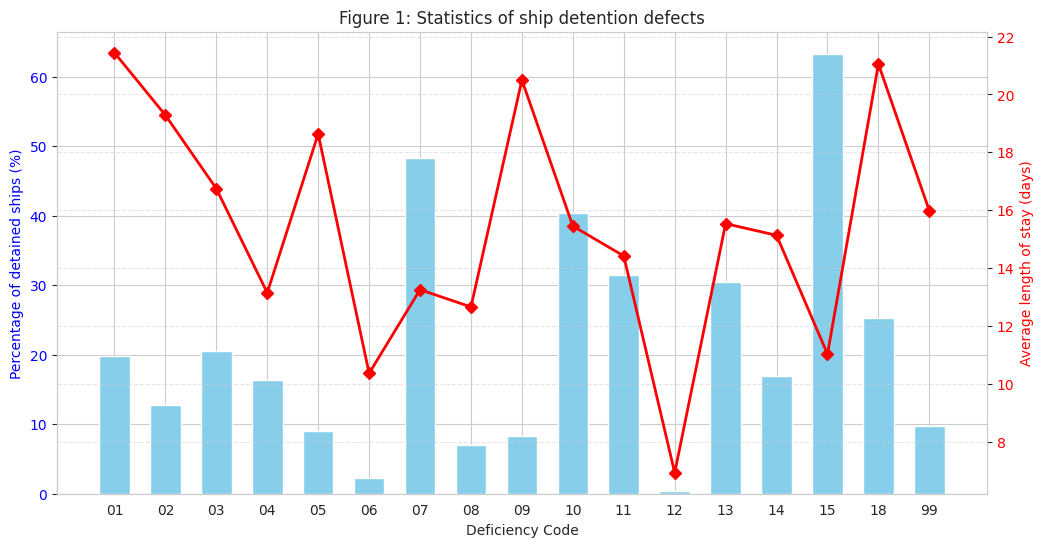

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot (Rate)
x = np.arange(len(stats_overall))
ax1.bar(x, stats_overall['Rate'], color='skyblue', label='Rate of detention', width=0.6)
ax1.set_xlabel('Deficiency Code')
ax1.set_ylabel('Percentage of detained ships (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(stats_overall['Code'])

# Line plot (Time) - Second Y axis
ax2 = ax1.twinx()
ax2.plot(x, stats_overall['Avg_Time'], color='red', marker='D', label='Avg length of stay', linewidth=2)
ax2.set_ylabel('Average length of stay (days)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Figure 1: Statistics of ship detention defects')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Figure 2: Average rate of detention

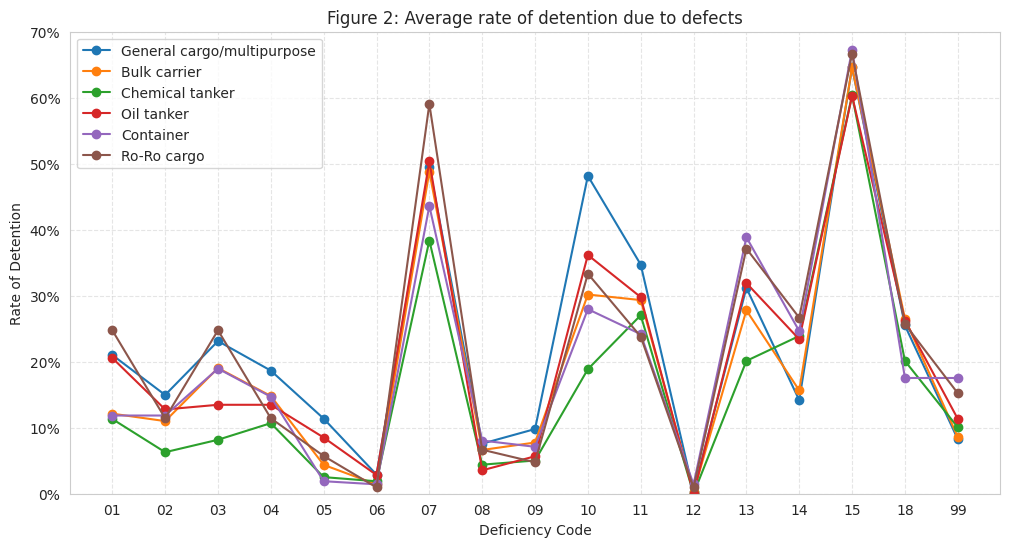

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

plt.figure(figsize=(12, 6))

# Φτιάχνω μια “σταθερή” λίστα codes (ώστε να υπάρχουν όλα και να μπουν ως ticks)
codes = [f"{i:02d}" for i in range(1, 16)] + ["18"] + ["99"]

for ship in target_ships:
    subset = stats_by_ship_df[stats_by_ship_df["Ship_Type"] == ship].copy()

    # εξασφάλισε ότι το Code είναι string με leading zeros
    subset["Code"] = subset["Code"].astype(str).str.zfill(2)

    # βάζω όλα τα codes με σειρά + fill 0 όπου λείπει
    full_codes = pd.DataFrame({"Code": codes})
    subset = full_codes.merge(subset, on="Code", how="left").fillna({"Rate": 0})

    plt.plot(subset["Code"], subset["Rate"], marker="o", label=ship)

# --- X axis: όλα τα ticks όπως στο paper
plt.xticks(codes)  # θα γράψει 01 02 ... 18 99

# --- Y axis: ποσοστά 0%–70%
plt.ylim(0, 70)                 # ΑΝ το Rate σου είναι ήδη σε % (π.χ. 35 σημαίνει 35%)
plt.gca().yaxis.set_major_locator(MultipleLocator(10))
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))

# Αν το Rate σου είναι 0–1 (π.χ. 0.35), τότε αντί για τα παραπάνω χρησιμοποίησε:
# plt.ylim(0, 0.70)
# plt.gca().yaxis.set_major_locator(MultipleLocator(0.10))
# plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.xlabel("Deficiency Code")
plt.ylabel("Rate of Detention")
plt.title("Figure 2: Average rate of detention due to defects")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Figure 3: Average days of detention

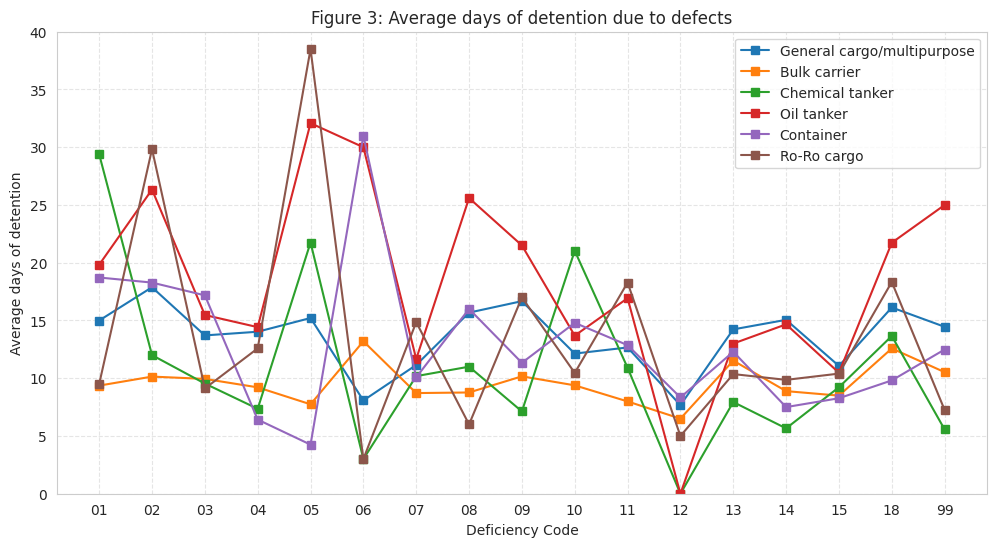

In [ ]:
plt.figure(figsize=(12, 6))

codes = [f"{i:02d}" for i in range(1, 16)] + ["18"] + ["99"]

for ship in target_ships:
    subset = stats_by_ship_df[stats_by_ship_df["Ship_Type"] == ship].copy()

    subset["Code"] = subset["Code"].astype(str).str.zfill(2)

    full_codes = pd.DataFrame({"Code": codes})
    subset = full_codes.merge(subset, on="Code", how="left").fillna(0)

    plt.plot(subset["Code"], subset["Avg_Time"], marker="s", label=ship)

plt.xticks(codes)
plt.ylim(0, 40)

from matplotlib.ticker import MultipleLocator
plt.gca().yaxis.set_major_locator(MultipleLocator(5))

plt.xlabel("Deficiency Code")
plt.ylabel("Average days of detention")
plt.title("Figure 3: Average days of detention due to defects")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

ΜΕΡΟΣ Α: Risk Matrix

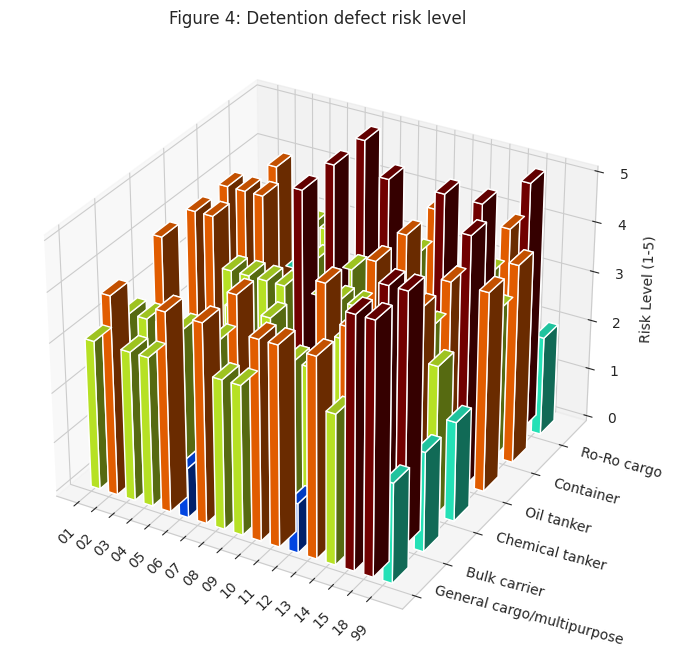

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Προετοιμασία δεδομένων για 3D plot
# X = Codes (0-16), Y = Ship Types (0-5), Z = Risk (1-5)
ship_map = {ship: i for i, ship in enumerate(target_ships)}
target_codes = list(range(0, 16)) + [18, 99]
code_map_int = {code: i for i, code in enumerate(sorted(stats_overall['Code'].unique()))}

x_vals = []
y_vals = []
z_vals = []
dx = []
dy = []
dz = []
colors = []

# Χρώματα(1=Πράσινο ... 5=Κόκκινο)
cmap = plt.get_cmap('jet')

for _, row in risk_df.iterrows():
    if row['Code'] not in code_map_int: continue

    x = code_map_int[row['Code']]
    y = ship_map[row['Ship_Type']]
    z = 0

    x_vals.append(x)
    y_vals.append(y)
    z_vals.append(z)

    dx.append(0.5) # Πλάτος μπάρας
    dy.append(0.5) # Βάθος μπάρας
    dz.append(row['Risk']) # Ύψος μπάρας = Risk Level

    colors.append(cmap((row['Risk'])/5))

ax.bar3d(x_vals, y_vals, z_vals, dx, dy, dz, color=colors)

ax.set_xticks(list(code_map_int.values()))
ax.set_xticklabels(list(code_map_int.keys()), rotation=45)
ax.set_yticks(list(ship_map.values()))
ax.set_yticklabels(list(ship_map.keys()), rotation=-15, va='center', ha='left')
ax.set_zlabel('Risk Level (1-5)')
ax.set_title('Figure 4: Detention defect risk level')
plt.show()

ΜΕΡΟΣ Α: Association Rules

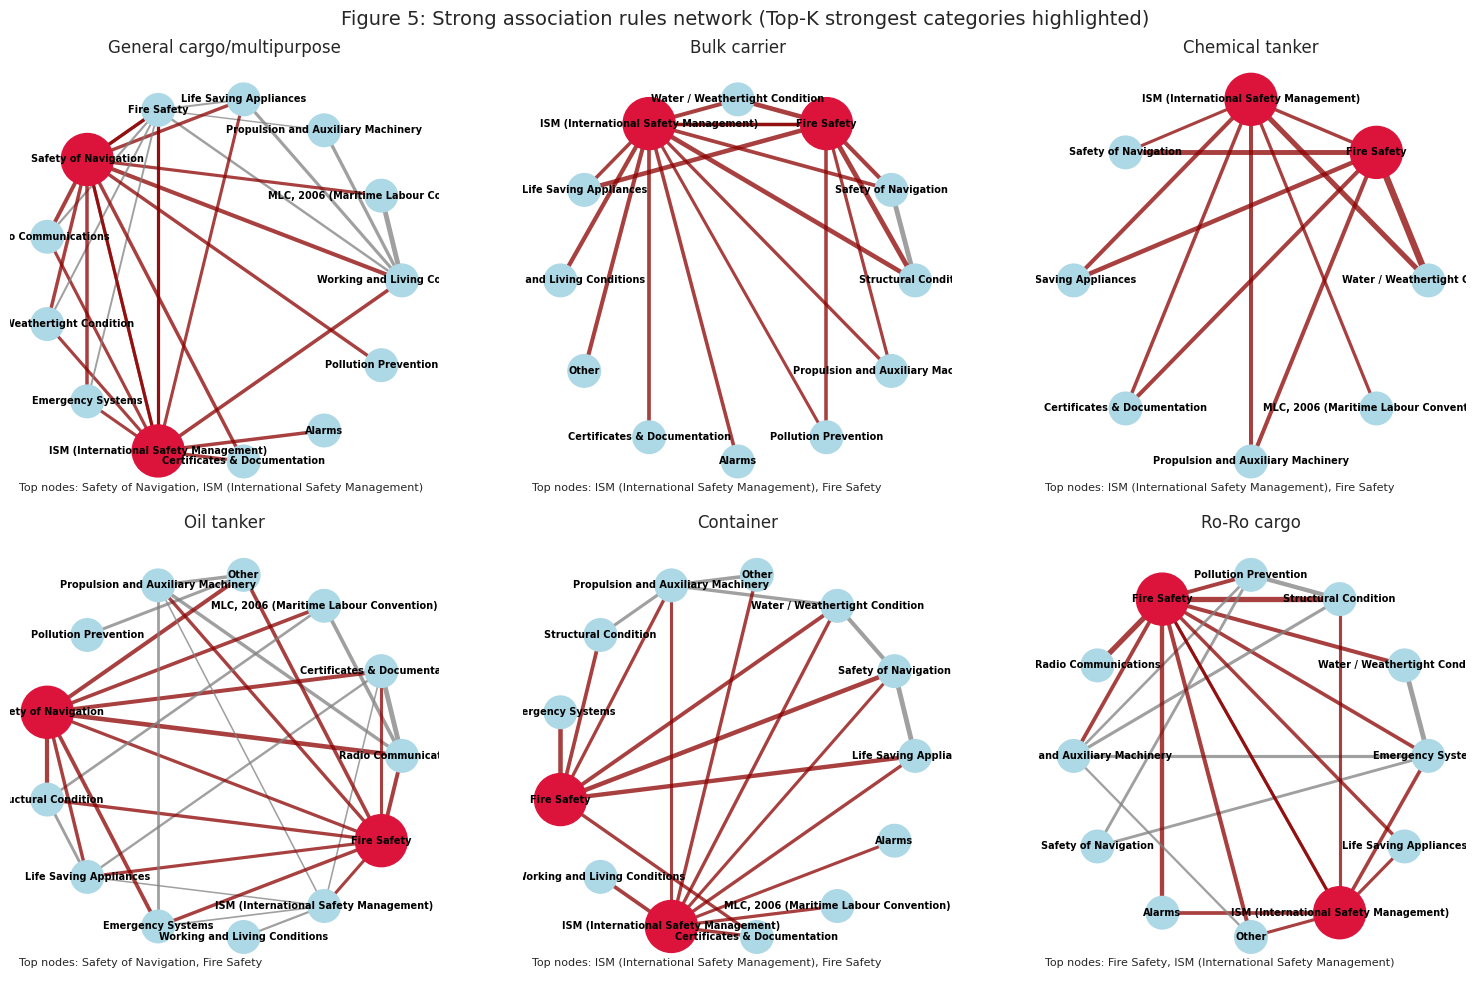

In [ ]:
# ==========================================
# Figure 5 – Strong association rules network
# Highlight: οι πραγματικά πιο "δυνατοί" κόμβοι (Top-K by weighted strength)
# με βάση τις κατηγορίες όπως είναι στα δεδομένα μου
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# -----------------------------
# 1) Ρυθμίσεις mining
# -----------------------------
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.5
MIN_LIFT = 1.1
TOP_RULES = 30     # πόσα rules κρατάω για το γράφημα (αν θες πιο "γεμάτο", βάλε 50)
TOP_K_NODES = 2    # πόσους "πιο δυνατούς" κόμβους θέλω να κάνω highlight ανά ship type

ml_data = df_main.groupby(['SHIP_IMO', 'Date of Release']).agg({
    'Ship_Type': 'first',
    'DET_DurationOfDetention': 'first',
    'Category': list
}).reset_index()





# -----------------------------
# 2) Φτιάχνω subplots 2x3 όπως paper
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ship in enumerate(target_ships):
    ax = axes[i]
    ax.set_title(ship)

    # Παίρνω transactions: λίστα κατηγοριών ανά detention event
    ship_tx = ml_data.loc[ml_data["Ship_Type"] == ship, "Category"].dropna().tolist()

    # Καθαρίζω τις λίστες μου (κρατάω strings, κόβω κενά, κάνω set μέσα στο event)
    cleaned_tx = []
    for t in ship_tx:
        if not isinstance(t, (list, tuple, set)):
            continue
        tt = [str(x).strip() for x in t if pd.notna(x) and str(x).strip() != ""]
        cleaned_tx.append(sorted(set(tt)))

    # Αν έχω λίγα events, δεν βγάζω αξιόπιστο δίκτυο
    if len(cleaned_tx) < 30:
        ax.text(0.5, 0.5, "Too few events", ha="center", va="center")
        ax.axis("off")
        continue

    # One-hot encoding
    te = TransactionEncoder()
    te_ary = te.fit(cleaned_tx).transform(cleaned_tx)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)

    # Frequent itemsets
    f_items = fpgrowth(df_trans, min_support=MIN_SUPPORT, use_colnames=True)

    if f_items.empty:
        ax.text(0.5, 0.5, "No Frequent Itemsets", ha="center", va="center")
        ax.axis("off")
        continue

    # Rules με confidence threshold + lift filter
    rules = association_rules(f_items, metric="confidence", min_threshold=MIN_CONFIDENCE)
    rules = rules[rules["lift"] >= MIN_LIFT].copy()

    # Κρατάω μόνο 1→1 rules για καθαρό network όπως paper
    rules = rules[(rules["antecedents"].apply(len) == 1) & (rules["consequents"].apply(len) == 1)]

    if rules.empty:
        ax.text(0.5, 0.5, "No Rules Found", ha="center", va="center")
        ax.axis("off")
        continue

    # Top rules by lift (για να μην “μπουκώνει” το δίκτυο)
    top_rules = rules.sort_values("lift", ascending=False).head(TOP_RULES)

    # -----------------------------
    # 3) Φτιάχνω graph με weight = lift
    # -----------------------------
    G = nx.DiGraph()
    for _, r in top_rules.iterrows():
        src = list(r["antecedents"])[0]
        dst = list(r["consequents"])[0]
        w = float(r["lift"])
        # Αν υπάρχει ήδη edge, κρατάω το max lift
        if G.has_edge(src, dst):
            G[src][dst]["weight"] = max(G[src][dst]["weight"], w)
        else:
            G.add_edge(src, dst, weight=w)

    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "Empty graph", ha="center", va="center")
        ax.axis("off")
        continue

    # -----------------------------
    # 4) Υπολογίζω "δύναμη" κόμβου = sum(weights) σε in+out edges
    #    και παίρνω τους Top-K για highlight
    # -----------------------------
    strength = {}
    for n in G.nodes():
        in_w = sum(G[u][n]["weight"] for u in G.predecessors(n))
        out_w = sum(G[n][v]["weight"] for v in G.successors(n))
        strength[n] = in_w + out_w

    top_nodes = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:TOP_K_NODES]
    highlight_nodes = {n for n, _ in top_nodes}

    # -----------------------------
    # 5) Styling: nodes/edges
    # -----------------------------
    pos = nx.circular_layout(G)

    # Node styling (highlight: μεγαλύτερο + κόκκινο)
    node_colors = []
    node_sizes = []
    for n in G.nodes():
        if n in highlight_nodes:
            node_colors.append("crimson")
            node_sizes.append(1400)
        else:
            node_colors.append("lightblue")
            node_sizes.append(550)

    # Edge styling:
    # - edges που ακουμπάνε highlighted nodes: πιο έντονες
    # - επιπλέον: width ∝ lift (ώστε να φαίνεται “strength” και οπτικά)
    weights = [G[u][v]["weight"] for u, v in G.edges()]
    w_min, w_max = (min(weights), max(weights)) if weights else (1.0, 1.0)

    edge_colors = []
    edge_widths = []
    for u, v, d in G.edges(data=True):
        w = d["weight"]
        # κλιμάκωση πλάτους με βάση lift
        base_width = 1.0 + 2.5 * (w - w_min) / (w_max - w_min + 1e-9)

        if (u in highlight_nodes) or (v in highlight_nodes):
            edge_colors.append("darkred")
            edge_widths.append(base_width + 1.2)
        else:
            edge_colors.append("gray")
            edge_widths.append(base_width)

    # Draw
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths, alpha=0.75, arrows=False)

    ax.axis("off")

    # Μικρό annotation: ποια nodes κάνω highlight (για να το ελέγχω εύκολα)
    # (Αν δεν το θες πάνω στο γράφημα, σβήσε τις 2 γραμμές)
    label_txt = ", ".join([f"{n}" for n, _ in top_nodes])
    ax.text(0.02, 0.02, f"Top nodes: {label_txt}", transform=ax.transAxes, fontsize=8)

# Αν έχω λιγότερα από 6 ship types, κλείνω τα υπόλοιπα
for j in range(len(target_ships), 6):
    axes[j].axis("off")

plt.suptitle("Figure 5: Strong association rules network (Top-K strongest categories highlighted)", fontsize=14)
plt.tight_layout()
plt.show()


Figure 6: Radar Chart

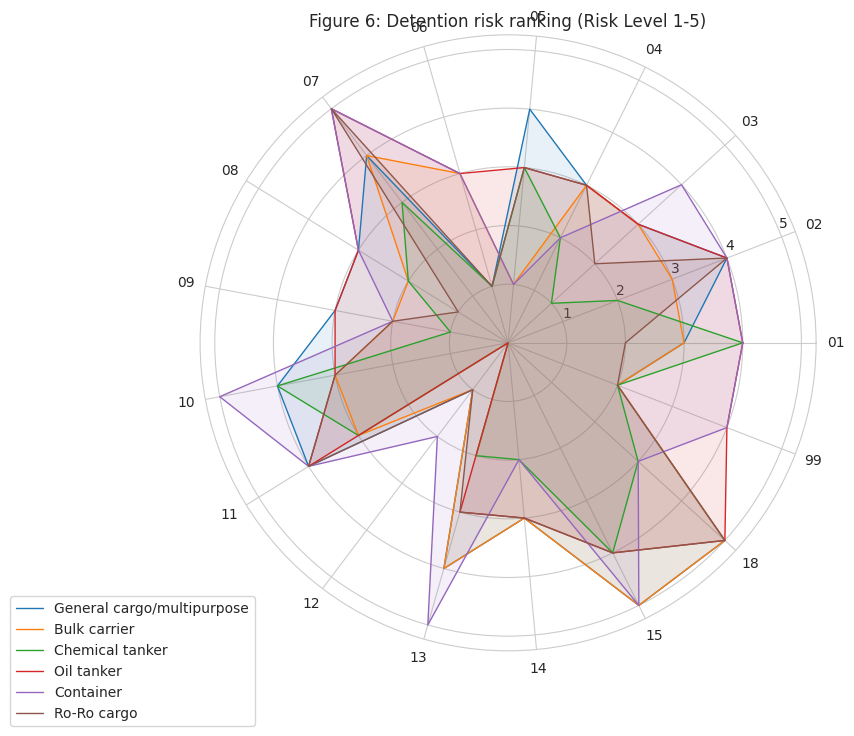

In [ ]:
# Υπολογισμός Ranking Goal(i)
# Goal = w1*CC_UH + ... (Εδώ απλοποιούμε: Goal = Sum(Lift * Risk_Weight))
# Για να βγάλουμε Radar Chart (Rank 1-19), θα χρησιμοποιήσουμε το συνολικό Risk Score που βγάλαμε πριν

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Γωνίες για το ραντάρ (17 σημεία)
categories = sorted(list(category_map.values()))
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Κλείσιμο κύκλου

# Axis labels
plt.xticks(angles[:-1], categories)

# Plot ανά πλοίο
for ship in target_ships:
    ship_risk = risk_df[risk_df['Ship_Type'] == ship].set_index('Code')

    # Δημιουργία λίστας τιμών (Risk Level) για τις κατηγορίες 01-17
    values = []
    for code in categories:
        if code in ship_risk.index:
            values.append(ship_risk.loc[code, 'Risk'])
        else:
            values.append(0) # 0 αν δεν υπάρχει

    values += values[:1] # Κλείσιμο

    ax.plot(angles, values, linewidth=1, linestyle='solid', label=ship)
    ax.fill(angles, values, alpha=0.1)

plt.title('Figure 6: Detention risk ranking (Risk Level 1-5)')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

ΜΕΡΟΣ Β: Επέκταση (ML με PCA & GridSearch)

Κατανομή High_Risk:
High_Risk
0    1697
1    1526
Name: count, dtype: int64

Ποσοστιαία κατανομή:
High_Risk
0    0.526528
1    0.473472
Name: proportion, dtype: float64

Τρέχω GridSearchCV ΧΩΡΙΣ PCA...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

[Χωρίς PCA] Καλύτερες παράμετροι: {'rf__max_depth': 20, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
[Χωρίς PCA] Καλύτερο F1 score (CV): 0.614

[Χωρίς PCA] Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.652     0.688     0.669       509
           1      0.630     0.592     0.610       458

    accuracy                          0.642       967
   macro avg      0.641     0.640     0.640       967
weighted avg      0.642     0.642     0.641       967



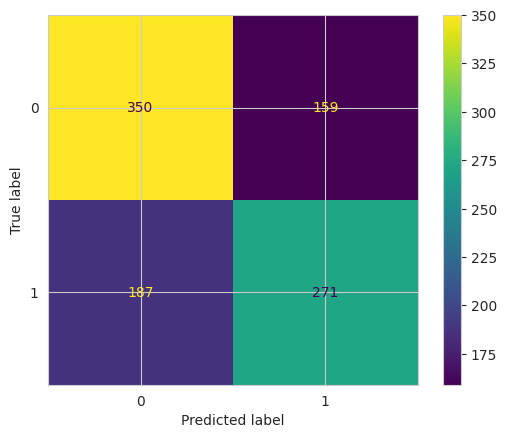

X_test_tr shape: (967, 23)
shap_vals_pos shape: (967, 23)
n_features: 23
RF n_features_in_: 23


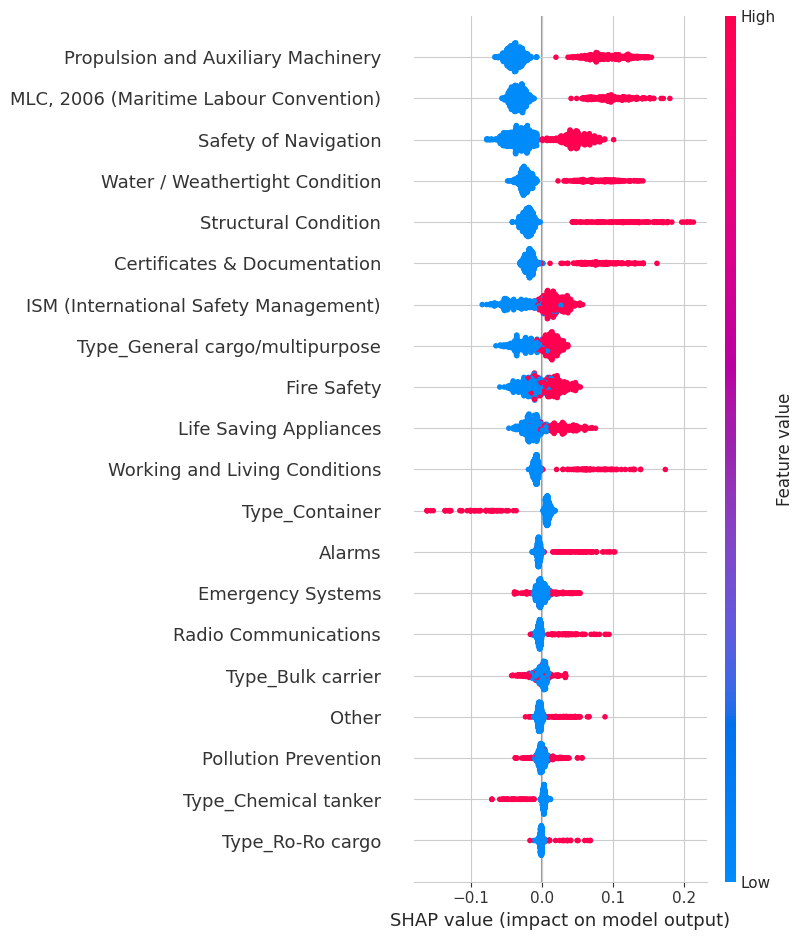

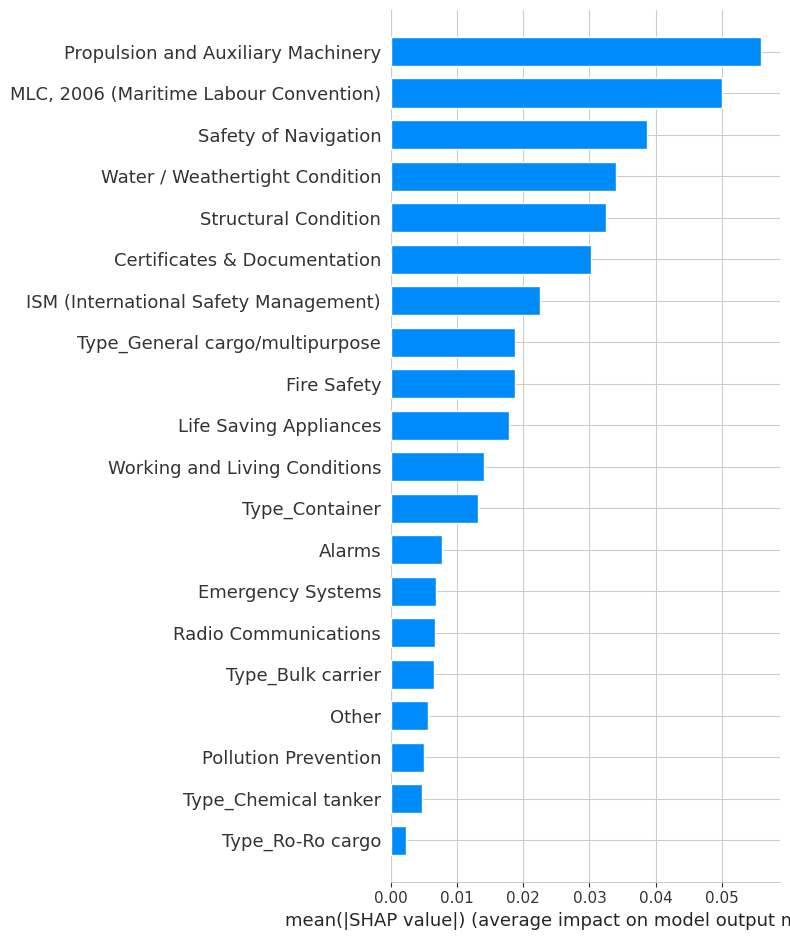

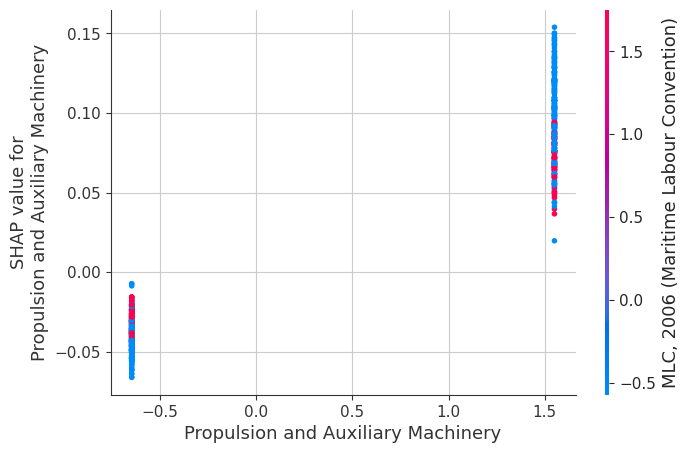

In [ ]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import shap


# 1) Προετοιμασία Δεδομένων
# Ομαδοποιώ τα δεδομένα ανά πλοίο και ημερομηνία release
ml_data = df_main.groupby(['SHIP_IMO', 'Date of Release']).agg({
    'Ship_Type': 'first',
    'DET_DurationOfDetention': 'first',
    'Category': list
}).reset_index()

# Ορίζω το target: High_Risk = 1 αν η διάρκεια κράτησης είναι πάνω από το median
median_days = ml_data['DET_DurationOfDetention'].median()
ml_data['High_Risk'] = (ml_data['DET_DurationOfDetention'] > median_days).astype(int)

# Ελέγχω την κατανομή των κλάσεων
print("Κατανομή High_Risk:")
print(ml_data['High_Risk'].value_counts())
print("\nΠοσοστιαία κατανομή:")
print(ml_data['High_Risk'].value_counts(normalize=True))


# 2) Feature Engineering
# Μετατρέπω τις πολλαπλές κατηγορίες ελαττωμάτων σε binary features
mlb = MultiLabelBinarizer()
X_defects = pd.DataFrame(
    mlb.fit_transform(ml_data['Category']),
    columns=mlb.classes_,
    index=ml_data.index
)

# Κάνω one-hot encoding στο Ship_Type
X_ships = pd.get_dummies(ml_data['Ship_Type'], prefix='Type')

# Συνδυάζω όλα τα features
X = pd.concat([X_defects, X_ships], axis=1)
y = ml_data['High_Risk']


# 3) Train / Test Split
# Χωρίζω τα δεδομένα κρατώντας την ίδια αναλογία κλάσεων (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# 4) Pipeline ΧΩΡΙΣ PCA

pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])


# 5) GridSearchCV – Υπερπαράμετροι
param_grid_no_pca = {
    'rf__n_estimators': [100, 200, 400],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

print("\nΤρέχω GridSearchCV ΧΩΡΙΣ PCA...")
grid_search_no_pca = GridSearchCV(
    estimator=pipeline_no_pca,
    param_grid=param_grid_no_pca,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_no_pca.fit(X_train, y_train)


# 6) Αποτελέσματα GridSearch
print(f"\n[Χωρίς PCA] Καλύτερες παράμετροι: {grid_search_no_pca.best_params_}")
print(f"[Χωρίς PCA] Καλύτερο F1 score (CV): {grid_search_no_pca.best_score_:.3f}")


# 7) Αξιολόγηση στο Test Set
best_model_no_pca = grid_search_no_pca.best_estimator_
y_pred_no_pca = best_model_no_pca.predict(X_test)

print("\n[Χωρίς PCA] Classification Report (Test Set):")
print(classification_report(y_test, y_pred_no_pca, digits=3))

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred_no_pca)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot()
plt.show()


# SHAP Explainability (Random Forest)

feature_names = X_train.columns

# Μετασχηματισμός δεδομένων όπως τα βλέπει το RF (μετά το scaler)
X_train_tr = best_model_no_pca.named_steps['scaler'].transform(X_train)
X_test_tr  = best_model_no_pca.named_steps['scaler'].transform(X_test)

rf_best = best_model_no_pca.named_steps['rf']

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_tr)

# Θέλουμε SHAP για High_Risk = 1
if isinstance(shap_values, list):

    shap_vals_pos = shap_values[1]
else:
    # νέο format: array (n_samples, n_features, n_classes)
    if shap_values.ndim == 3:
        shap_vals_pos = shap_values[:, :, 1]
    else:
        shap_vals_pos = shap_values

print("X_test_tr shape:", X_test_tr.shape)
print("shap_vals_pos shape:", shap_vals_pos.shape)
print("n_features:", len(feature_names))
print("RF n_features_in_:", rf_best.n_features_in_)

# Summary plot (beeswarm)
shap.summary_plot(
    shap_vals_pos,
    features=X_test_tr,
    feature_names=feature_names,
    show=True
)

# Summary plot (bar)
shap.summary_plot(
    shap_vals_pos,
    features=X_test_tr,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# Dependence plot για το πιο σημαντικό feature (βάσει mean |SHAP|)
mean_abs = np.abs(shap_vals_pos).mean(axis=0)
top_idx = int(np.argmax(mean_abs))
top_feature = feature_names[top_idx]

shap.dependence_plot(
    top_feature,
    shap_vals_pos,
    X_test_tr,
    feature_names=feature_names,
    show=True
)



Τρέχω GridSearchCV με PCA...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Καλύτερες παράμετροι: {'rf__max_depth': 10, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Καλύτερο F1 score (CV): 0.618

Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.643     0.676     0.659       509
           1      0.618     0.583     0.600       458

    accuracy                          0.632       967
   macro avg      0.631     0.629     0.630       967
weighted avg      0.631     0.632     0.631       967



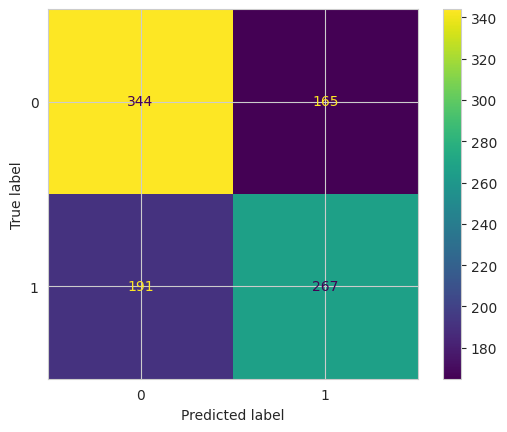


Το PCA κράτησε 21 συνιστώσες για το 95% της διακύμανσης.

Τρέχω GridSearchCV ΧΩΡΙΣ PCA...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

[Χωρίς PCA] Καλύτερες παράμετροι: {'rf__max_depth': 20, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
[Χωρίς PCA] Καλύτερο F1 score (CV): 0.614

[Χωρίς PCA] Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.652     0.688     0.669       509
           1      0.630     0.592     0.610       458

    accuracy                          0.642       967
   macro avg      0.641     0.640     0.640       967
weighted avg      0.642     0.642     0.641       967



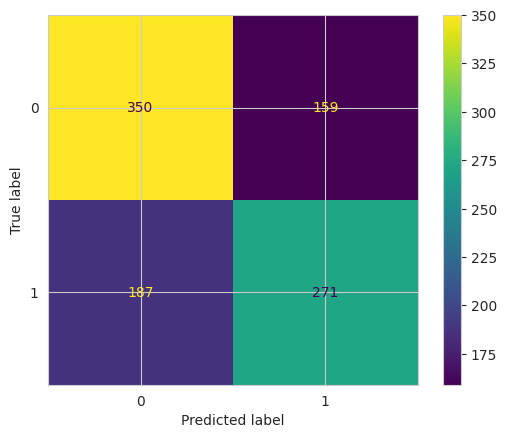

In [ ]:
from sklearn.decomposition import PCA

# 4) Pipeline: StandardScaler -> PCA -> Random Forest
# Κανονικοποιώ τα δεδομένα, εφαρμόζω PCA και μετά Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),  # κρατάω το 95% της πληροφορίας
    ('rf', RandomForestClassifier(random_state=42))
])


# 5) GridSearchCV – Υπερπαράμετροι
# Ορίζω το grid για βελτιστοποίηση του Random Forest
param_grid = {
    'rf__n_estimators': [100, 200, 400],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

print("\nΤρέχω GridSearchCV με PCA...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',      # προτιμώ f1 λόγω πιθανής ανισορροπίας κλάσεων
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


# 6) Αποτελέσματα GridSearch
# ------------------------------------------------
print(f"\nΚαλύτερες παράμετροι: {grid_search.best_params_}")
print(f"Καλύτερο F1 score (CV): {grid_search.best_score_:.3f}")


# 7) Αξιολόγηση στο Test Set
# ------------------------------------------------
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


# 8) Πληροφορίες PCA
# Βλέπω πόσες κύριες συνιστώσες χρειάστηκαν για το 95% της διακύμανσης
pca_step = best_model.named_steps['pca']
n_components = pca_step.n_components_
print(f"\nΤο PCA κράτησε {n_components} συνιστώσες για το 95% της διακύμανσης.")


# 9) Σύγκριση χωρίς PCA
# Δημιουργώ pipeline χωρίς PCA για σύγκριση απόδοσης
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid_no_pca = {
    'rf__n_estimators': [100, 200, 400],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

print("\nΤρέχω GridSearchCV ΧΩΡΙΣ PCA...")
grid_search_no_pca = GridSearchCV(
    estimator=pipeline_no_pca,
    param_grid=param_grid_no_pca,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_no_pca.fit(X_train, y_train)

print(f"\n[Χωρίς PCA] Καλύτερες παράμετροι: {grid_search_no_pca.best_params_}")
print(f"[Χωρίς PCA] Καλύτερο F1 score (CV): {grid_search_no_pca.best_score_:.3f}")

best_model_no_pca = grid_search_no_pca.best_estimator_
y_pred_no_pca = best_model_no_pca.predict(X_test)

print("\n[Χωρίς PCA] Classification Report (Test Set):")
print(classification_report(y_test, y_pred_no_pca, digits=3))

cm2 = confusion_matrix(y_test, y_pred_no_pca)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot()
plt.show()


Αποτελέσματα


     ΣΥΝΟΠΤΙΚΗ ΠΑΡΟΥΣΙΑΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
1. Μετρικές Απόδοσης (Test Set):
   - Accuracy (Ακρίβεια): 63.19%
   - Precision (Ακρίβεια Θετικών): 61.81%
   - Recall (Ανάκληση): 58.30%
   - F1-Score: 60.00%
   - ROC-AUC Score: 0.500

2. Βέλτιστες Παράμετροι (Best Params):
   {'rf__max_depth': 10, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}


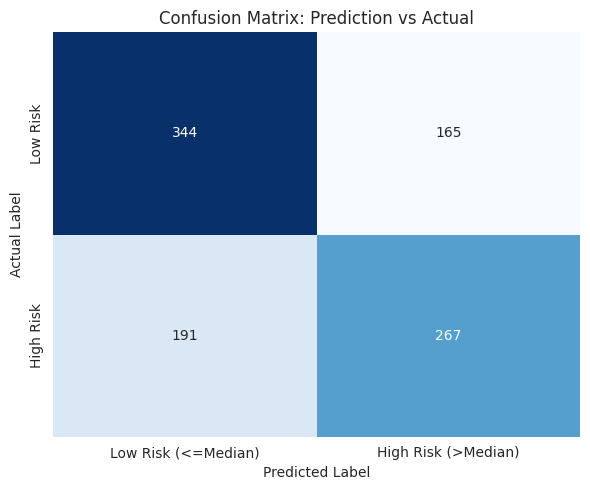

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

print("\n" + "="*40)
print("     ΣΥΝΟΠΤΙΚΗ ΠΑΡΟΥΣΙΑΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ")
print("="*40)

# 1. Υπολογισμός Βασικών Μετρικών
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Προσπάθεια υπολογισμού ROC-AUC (αν το μοντέλο υποστηρίζει predict_proba)
try:
    y_prob = best_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
except:
    roc_auc = 0.5
    y_prob = None

print(f"1. Μετρικές Απόδοσης (Test Set):")
print(f"   - Accuracy (Ακρίβεια): {acc:.2%}")
print(f"   - Precision (Ακρίβεια Θετικών): {prec:.2%}")
print(f"   - Recall (Ανάκληση): {rec:.2%}")
print(f"   - F1-Score: {f1:.2%}")
print(f"   - ROC-AUC Score: {roc_auc:.3f}")

print(f"\n2. Βέλτιστες Παράμετροι (Best Params):")
print(f"   {grid_search.best_params_}")

# 3. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Risk (<=Median)', 'High Risk (>Median)'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix: Prediction vs Actual')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 4. ROC Curve Plot (Αν υπάρχει y_prob)
if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()

print("="*40)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# (α) Βασικά στοιχεία του dataset / στόχου
n_events = ml_data.shape[0]
median_days = ml_data['DET_DurationOfDetention'].median()

class_counts = ml_data['High_Risk'].value_counts().to_dict()
class_pct = (ml_data['High_Risk'].value_counts(normalize=True) * 100).round(2).to_dict()

# (β) Cross-validation αποτέλεσμα από GridSearch
best_params = grid_search.best_params_
best_cv = grid_search.best_score_

# (γ) Test set metrics
test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# (δ) PCA summary
pca_step = best_model.named_steps['pca']
n_components = pca_step.n_components_

# (ε) Εκτύπωση σύνοψης
print("\n" + "="*60)
print("ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ – ΜΕΡΟΣ Β (Classification)")
print("="*60)

print(f"• Σύνολο detention events (transactions): {n_events}")
print(f"• Median detention days (threshold): {median_days:.2f}")
print("• Κατανομή στόχου High_Risk (0/1):")
print(f"   - 0: {class_counts.get(0,0)} ({class_pct.get(0,0)}%)")
print(f"   - 1: {class_counts.get(1,0)} ({class_pct.get(1,0)}%)")

print("\n• Βέλτιστες παράμετροι GridSearch:")
for k, v in best_params.items():
    print(f"   - {k}: {v}")

print(f"\n• Best CV Accuracy (cv=3): {best_cv:.3f}")
print(f"• Test Accuracy: {test_acc:.3f}")

print("\n• Confusion Matrix (Test):")
print(cm)
print("  (γραμμές = true, στήλες = predicted)")

print(f"\n• PCA: κράτησα {n_components} components για να εξηγήσω 95% variance.")

print("\n• Τελικό Classification Report (Test) – ήδη εκτυπώθηκε παραπάνω.")
print("="*60)



ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ – ΜΕΡΟΣ Β (Classification)
• Σύνολο detention events (transactions): 3223
• Median detention days (threshold): 5.00
• Κατανομή στόχου High_Risk (0/1):
   - 0: 1697 (52.65%)
   - 1: 1526 (47.35%)

• Βέλτιστες παράμετροι GridSearch:
   - rf__max_depth: 10
   - rf__min_samples_leaf: 2
   - rf__min_samples_split: 5
   - rf__n_estimators: 200

• Best CV Accuracy (cv=3): 0.618
• Test Accuracy: 0.632

• Confusion Matrix (Test):
[[344 165]
 [191 267]]
  (γραμμές = true, στήλες = predicted)

• PCA: κράτησα 21 components για να εξηγήσω 95% variance.

• Τελικό Classification Report (Test) – ήδη εκτυπώθηκε παραπάνω.
